In [1]:
# one term function with given pattern of derivatives
def avrgterm(todo, alpha, beta, gamma, delta, dmu, dalpha):
    f = dmu[len(todo[0])-1][(beta,) + todo[0]]
    s = dalpha[len(todo[1])-1][(alpha, delta,) + todo[1]]
    t = dmu[len(todo[2])-1][(gamma,) + todo[2]]

    return f * s * t

# average over given suscept_tensor_comp
def orientavr(suscept_tensor_comp, todo, dmu, dalpha):
    ders_avrg = []
    
    for alpha in suscept_tensor_comp[0]:
        for beta in suscept_tensor_comp[1]:
            for gamma in suscept_tensor_comp[2]:
                for delta in suscept_tensor_comp[3]:
                    
                    ders_avrg.append(avrgterm(todo, alpha, beta, gamma, delta, dmu, dalpha))
                    
    avrgders = sum(ders_avrg) / len(ders_avrg)
    return avrgders

In [95]:
# w1, w1-w2
import math
import numpy as np


# electrical anharmonicity for all normal mode pairs
# @np.vectorize
def el_anhALLab(data, settings):
    """
    """
    t2 = settings['el_t2']
    
    w1, w2, w, deriv_mu, deriv_alpha, Gamma, Delta, suscept_tensor_comps, F = data
    w_0 = 0
    
    totalres = np.zeros((len(w1), len(w2)), dtype='complex128')
        
    for a in range(len(w)):
        for b in range(len(w)):
            firstfrac = 1/ w[a] / w[b]
            
            # term 1 --------------------------
            resonance1_1 = (w[a] + w[b] - Delta['ab']) - w[a] + (w1-w2) - Gamma * 1j
            resonance2_1 = w_0 - w[a] + w1 - Gamma * 1j
                    
            todo1 = [(a,), (b,), (a, b,)]
            avrgders = orientavr(suscept_tensor_comps, todo1, deriv_mu, deriv_alpha)
            # avrgders = 1
            
            term1 = avrgders / resonance1_1 / resonance2_1
            
            if t2:
                # term 2 --------------------------
                resonance1_2 = w[b] - w[a] + (w1-w2) - Gamma * 1j
                resonance2_2 = w_0 - w[a] + w1 - Gamma * 1j

                todo2 = [(a,), (a, b,), (b,)]
                avrgders2 = orientavr(suscept_tensor_comps, todo2, deriv_mu, deriv_alpha)
                # avrgders2 = 1
                
                term2 = avrgders2 / resonance1_2 / resonance2_2
                # print('EL term2-term1', max(term2.flatten())-max(term1.flatten()))
                
            else:
                term2 = 0
            
            totalres += firstfrac * (term1+ term2)
            
    return totalres/24.

# 
def el_anh_ab(a, b, data, settings):
    """
    """
    t2 = settings['el_t2']
    
    w1, w2, w, deriv_mu, deriv_alpha, Gamma, Delta, suscept_tensor_comps, F = data
    w1mw2 = w1-w2
    w_0 = 0

    totalres = np.zeros((len(w1), len(w2)), dtype='complex128')
    
    firstfrac = 1/ w[a] / w[b]
    
    # term 1 --------------------------
    resonance1_1 = (w[a] + w[b] - Delta['ab']) - w[a] + (w1-w2) - Gamma * 1j
    resonance2_1 = w_0 - w[a] + w1 - Gamma * 1j
    
    # averaging
    todo1 = [(a,), (b,), (a, b,)]
    avrgders = orientavr(suscept_tensor_comps, todo1, deriv_mu, deriv_alpha)
    avrgders = 1
    
    term1 = avrgders / resonance1_1 / resonance2_1
    
    if t2:
        # term 2 --------------------------
        resonance1_2 = w[b] - w[a] + (w1-w2) - Gamma * 1j
        resonance2_2 = w_0 - w[a] + w1 - Gamma * 1j

        # averaging
        todo2 = [(a,), (a, b,), (b,)]
        avrgders2 = orientavr(suscept_tensor_comps, todo2, deriv_mu, deriv_alpha)
        avrgders2 = 1

        term2 = avrgders2 / resonance1_2 / resonance2_2
        # print('EL term2-term1', max(term2.flatten())-max(term1.flatten()))
        
    else:
        term2 = 0
            
    totalres += firstfrac * (term1+term2)
    
    return totalres/24. #* 10**5


def mech_anh(data, settings):
    on = settings['mech_on']
    t2 = settings['mech_t2']
    t3 = settings['mech_t3']
    
    w1, w2, w, deriv_mu, deriv_alpha, Gamma, Delta, suscept_tensor_comps, F = data
    w1mw2 = w1-w2
    w_0 = 0
    
    totalres = np.zeros((len(w1), len(w2)), dtype='complex128')
    # totalres = []
    
    if not on:
        return totalres
    
    else:
    
        for a in range(len(w)):
            for b in range(len(w)):
                for c in range(len(w)):

                    firstfrac = 1 / w[a] / w[b] / w[c]

                    # term 1 -------------------------- 
                    fracs = 1 / ((w[a] + w[b] + w[c] - Delta['abc']) - w_0) + 1 / (w[c] - (w[a] + w[b] - Delta['ab']))

                    resonance1_1 = (w[a] + w[b] - Delta['ab']) - w[a] - w1mw2 - Gamma * 1j
                    resonance2_1 = w_0 - w[a] - Gamma * 1j

                    # averaging
                    todo1 = [(a,), (b,), (c,)]
                    avrgders = orientavr(suscept_tensor_comps, todo1, deriv_mu, deriv_alpha)
                    avrgders = 1
                    
                    term1 = avrgders * fracs * F[a, b, c] / resonance1_1 / resonance2_1

                    if t2:
                        # term 2 -------------------------- 
                        fracs2 = 1 / ((w[a] + w[b] - Delta['ab']) - w[c]) + 1 / ((w[b] + w[c] - Delta['bc']) - w[a])

                        resonance1_2 = w[c] - w[a] - w1mw2 - Gamma * 1j
                        resonance2_2 = w_0 - w[a] - Gamma * 1j

                        # averaging
                        todo2 = [(a,), (b,), (c,)]
                        avrgders2 = orientavr(suscept_tensor_comps, todo2, deriv_mu, deriv_alpha)
                        avrgders2 = 1
                        
                        term2 = avrgders2 * fracs2 * F[a, b, c] / resonance1_2 / resonance2_2
                        # print('MECH term2-term1', max(term2.flatten())-max(term1.flatten()))
                        
                    else:
                        term2 = 0

                    if t3:
                        # term 3 -------------------------- 
                        fracs3 = 1 / (w[a] - (w[a] + w[b] - Delta['ab'])) + 1 / (w[b] - w_0)

                        resonance1_3 = (w[a] + w[b] - Delta['ab']) - w[a] - w1mw2 - Gamma * 1j
                        resonance2_3 = w_0 - w[a] - Gamma * 1j

                        # averaging
                        todo3 = [(a,), (b,), (a,)]
                        avrgders3 = orientavr(suscept_tensor_comps, todo3, deriv_mu, deriv_alpha)
                        avrgders3 = 1

                        term3 = avrgders3 * fracs3 * F[a, b, c] / resonance1_3 / resonance2_3
                        # print('MECH term3-term1', max(term3.flatten())-max(term1.flatten()))
                        
                    else:
                        term3 = 0

                    totalres += firstfrac * (term1 + term2 + term3)
                    # totalres.append(firstfrac * (term1 + term2 + term3))

        return -totalres/48. #* 10**5


def spectrum(data, settings):
    w1mw2=settings['w1mw2_axis']
    prt=settings['printing']
    # compute the third dimension at each point on the grid
    ELanh = el_anhALLab(data, settings)
    MECHanh = mech_anh(data, settings)
    print()
    
    Z = abs(ELanh + MECHanh)**2
    
    print(Z) if prt else None

    for k, v in w.items():
        print(k, v) if prt else None
        
    return data[0], data[1], Z


%matplotlib widget
from ipywidgets import *
import matplotlib.pyplot as plt
from matplotlib.pyplot import cm

def plotspectrum(ranges, numbers, settings):
    # ALL PARAMETERS 
    w1_s, w1_e, w2_s, w2_e, Nfreqs = ranges
    w1, w2 = np.linspace(w1_s, w1_e, Nfreqs), np.linspace(w2_s, w2_e, Nfreqs)
    
    w1mw2=settings['w1mw2_axis']
    # w1, w2, w, deriv_mu, deriv_alpha, Gamma, Delta, suscept_tensor_comps, F = numbers
    
    xx, yy = np.meshgrid(w1, w2)
    numbers[0], numbers[1] = xx, yy
    
    # PLOTTING
    fig, ax = plt.subplots()
    fig.set_size_inches(11, 9)

    X, Y, Z = spectrum(numbers, settings)
    Z = Z#*10**18
    
    # print(numbers)
    xaxis = X
    ax.set_xlabel('w1', fontsize=18)

    if w1mw2:
        yaxis = X-Y
        ax.set_ylabel('w1-w2', fontsize=18)
    else:
        yaxis = Y
        ax.set_ylabel('w2', fontsize=18)
    
    cp = ax.contourf(xaxis, yaxis, Z)

    # ax.legend()

    cb = plt.colorbar(cp)
    # plt.grid()
    fig.set_tight_layout(True)

    ax.set_xticks(np.linspace(min(xaxis.flatten())-10, max(xaxis.flatten())+10, 25))
    ax.set_yticks(np.linspace(min(yaxis.flatten())-10, max(yaxis.flatten())+10, 25))
    
    ax.set_xlim(min(xaxis.flatten())-20, max(xaxis.flatten())+20)    
    ax.set_ylim(min(yaxis.flatten())-20, max(yaxis.flatten())+20)

    plt.xticks(rotation = 90)
    
    if not w1mw2 and settings['show_fundamentals']:
        for k, f in w.items():
            plt.axvline(x=f, color ='k', linewidth=0.5)
            plt.axhline(y=f, color ='k', linewidth=0.5)
    
    plt.show()

In [96]:
# DERIVATIVES SETUP

# deriv_mu_first[0, i] --- delta(mu_x)/delta(Q_i)
# deriv_mu_first[1, i] --- delta(mu_y)/delta(Q_i)
deriv_mu_first = np.array([14.1]*3*3).reshape(3, 3)

# deriv_mu_second[0, i, j] --- delta(mu_x)/delta(Q_i)/delta(Q_j)
# deriv_mu_second[1, i, j] --- delta(mu_y)/delta(Q_i)/delta(Q_j)
deriv_mu_second = np.array([22.1]*3*3*3).reshape(3, 3, 3)

deriv_mu = [deriv_mu_first, deriv_mu_second]

# deriv_alpha_first[0, 1, i] --- delta(alpha_xy)/delta(Q_i)
deriv_alpha_first = np.array([-7.1]*3*3*3).reshape(3, 3, 3)

# deriv_alpha_first[0, 1, i] --- delta(alpha_xy)/delta(Q_i)
# deriv_alpha_second[0, 1, i, j] --- delta(alpha_xy)/delta(Q_i)/delta(Q_j)
deriv_alpha_second = np.array([13.1]*3*3*3*3).reshape(3, 3, 3, 3)

deriv_alpha = [deriv_alpha_first, deriv_alpha_second]

suscept_tensor_comps = [[2], [2], [2], [2]]

Gamma = 0.0001
Delta = {'aa': 70, 'bb': 30, 'ab': 70, 'bc': 80, 'abc': 120}

w = {0: 1927.08382347, 1: 4545.77721188, 2: 4896.43798171}

F = np.zeros((len(w), len(w), len(w)))
F[0, 1, 2] = 170.24

w2_s = 800
w2_e = 5590
w1_s = w2_s-700
w1_e = w2_e+10#-700
Nfreqs = 50

ranges = (w1_s, w1_e, w2_s, w2_e, Nfreqs)
data = [[], [], w, deriv_mu, deriv_alpha, Gamma, Delta, suscept_tensor_comps, F]

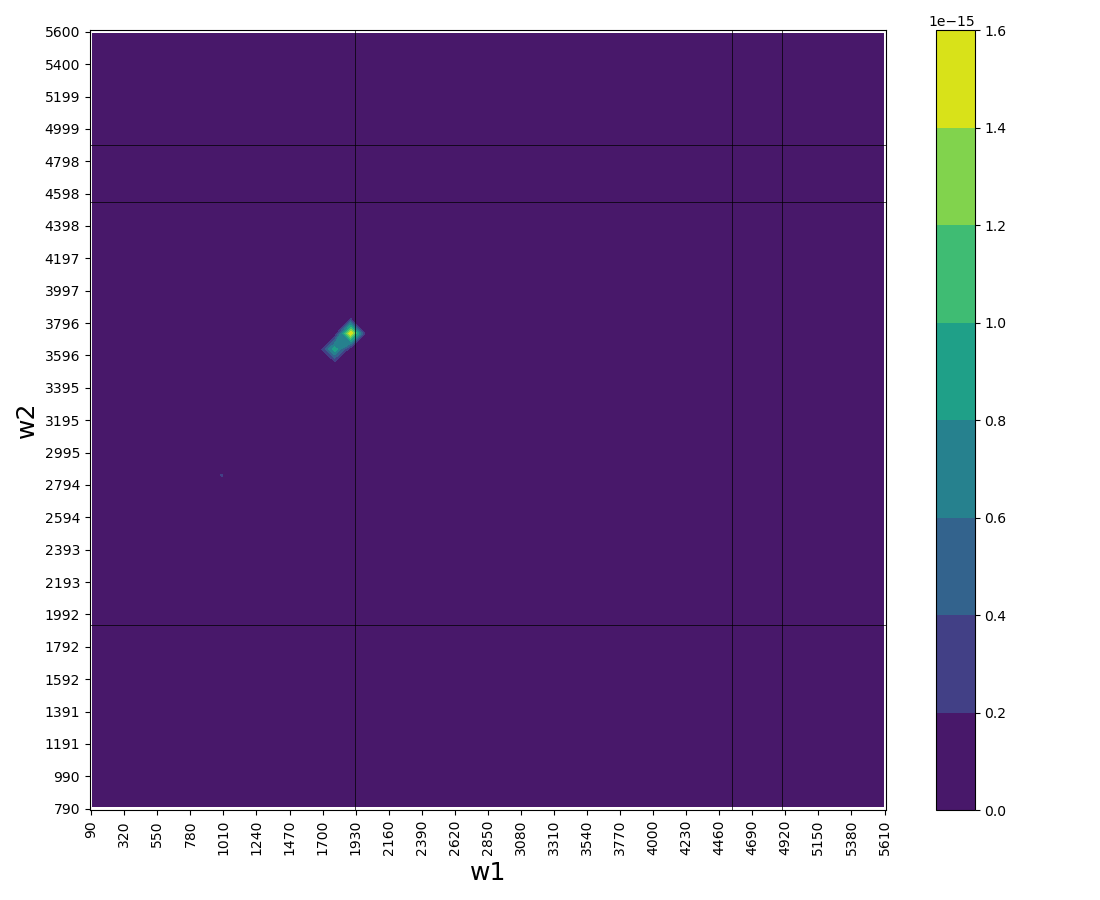

In [104]:
settings = {'el_t2':False, 
            'mech_on':False, 'mech_t2':False, 'mech_t3':False, 
            'w1mw2_axis': False, 'printing': False, 'show_fundamentals': True
            }
plotspectrum(ranges, data, settings)